In [1]:
# Python ≥3.5 is required
import sys
assert sys.version_info >= (3, 5)

# Scikit-Learn ≥0.20 is required
import sklearn
assert sklearn.__version__ >= "0.20"

# Common imports
import numpy as np
import pandas as pd
import os
from pathlib import Path

ROOT = Path('.').cwd().parent
DATA_DIR = ROOT/'dataset'

# to make this notebook's output stable across runs
np.random.seed(42)

# To plot pretty figures
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
mpl.rc('axes', labelsize=14)
mpl.rc('xtick', labelsize=12)
mpl.rc('ytick', labelsize=12)

# Where to save the figures
PROJECT_ROOT_DIR = "."
CHAPTER_ID = "datathon_image_phase_A"
IMAGES_PATH = os.path.join(PROJECT_ROOT_DIR, "images", CHAPTER_ID)
os.makedirs(IMAGES_PATH, exist_ok=True)

def save_fig(fig_id, tight_layout=True, fig_extension="png", resolution=300):
    path = os.path.join(IMAGES_PATH, fig_id + "." + fig_extension)
    print("Saving figure", fig_id)
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format=fig_extension, dpi=resolution)

### ĐỌC DỮ LIỆU

In [2]:
sales = pd.read_csv(DATA_DIR/"sales.csv")
orders = pd.read_csv(DATA_DIR/"orders.csv")
order_items = pd.read_csv(DATA_DIR/"order_items.csv")
products = pd.read_csv(DATA_DIR/"products.csv")
geography = pd.read_csv(DATA_DIR/"geography.csv")
payments = pd.read_csv(DATA_DIR/"payments.csv")
web_traffic = pd.read_csv(DATA_DIR/"web_traffic.csv")

C:\Users\Admin\AppData\Local\Temp\ipykernel_20324\2552945658.py:3: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  order_items = pd.read_csv(DATA_DIR/"order_items.csv")


### định dạng lại ngày tháng

In [3]:
sales["Date"] = pd.to_datetime(sales["Date"])
orders["order_date"] = pd.to_datetime(orders["order_date"])
web_traffic["date"] = pd.to_datetime(web_traffic["date"])

Saving figure daily_revenue_trend


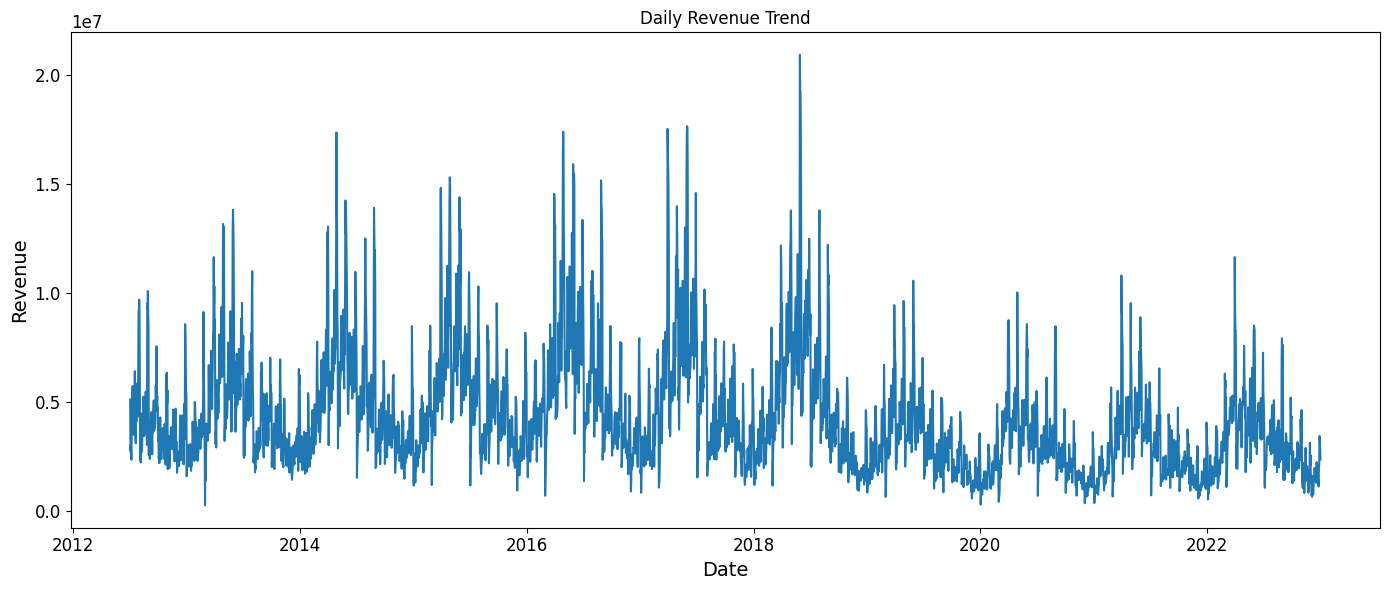

In [4]:
sales = sales.sort_values("Date")

plt.figure(figsize=(14,6))
plt.plot(sales["Date"], sales["Revenue"])
plt.title("Daily Revenue Trend")
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.tight_layout()
save_fig('daily_revenue_trend')
plt.show()


Saving figure monthly_revenue


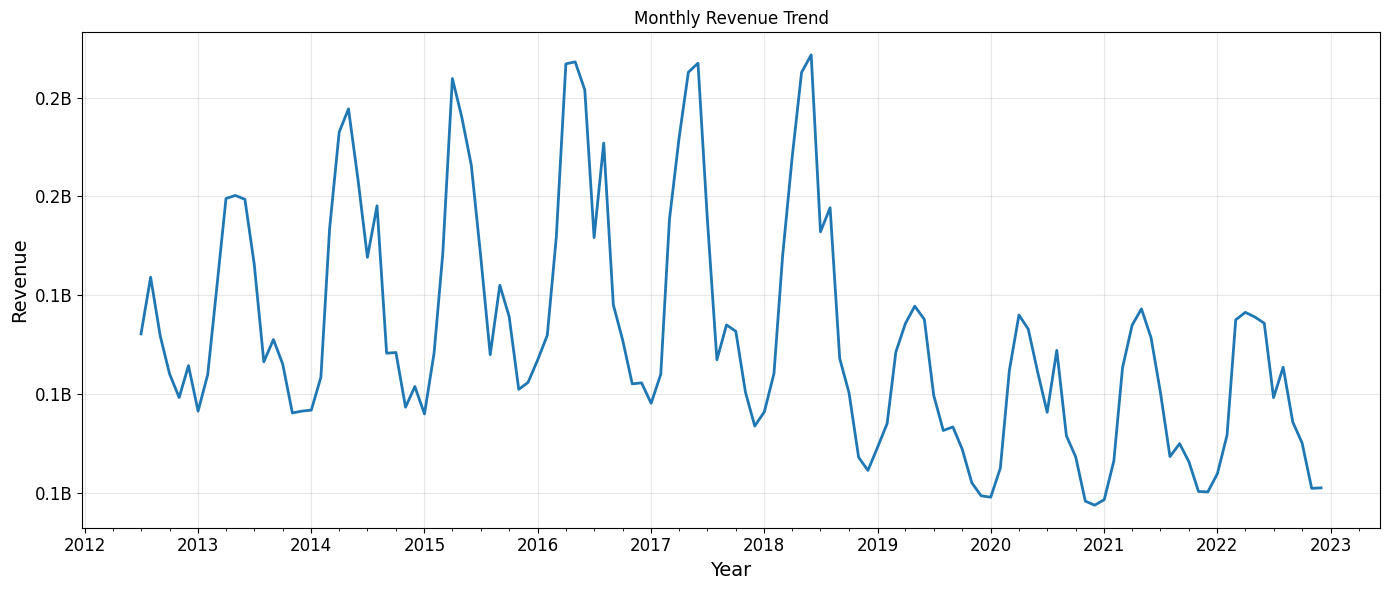

In [5]:
import matplotlib.dates as mdates
from matplotlib.ticker import FuncFormatter

monthly_sales = sales.copy()
monthly_sales["year_month"] = monthly_sales["Date"].dt.to_period("M").dt.to_timestamp()

monthly_sales = (
    monthly_sales
    .groupby("year_month", as_index=False)["Revenue"]
    .sum()
)

plt.figure(figsize=(14, 6))

plt.plot(
    monthly_sales["year_month"],
    monthly_sales["Revenue"],
    linewidth=2
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Year")
plt.ylabel("Revenue")

# Hiển thị mỗi năm 1 mốc trên trục X
plt.gca().xaxis.set_major_locator(mdates.YearLocator(1))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

# Nếu muốn có tick phụ theo quý
plt.gca().xaxis.set_minor_locator(mdates.MonthLocator(interval=3))

# Format trục Y cho dễ đọc: billion
plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"{x/1e9:.1f}B")
)

plt.grid(True, alpha=0.3)
plt.tight_layout()

save_fig("monthly_revenue")
plt.show()


Saving figure avg_month_revenue


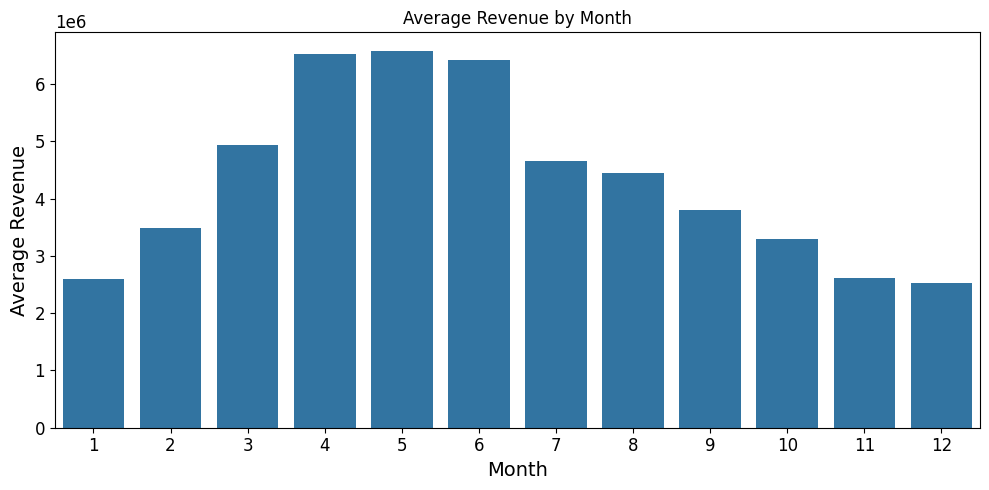

In [6]:
sales["year"] = sales["Date"].dt.year
sales["month"] = sales["Date"].dt.month

month_seasonality = sales.groupby("month", as_index=False)["Revenue"].mean()

plt.figure(figsize=(10,5))
sns.barplot(data=month_seasonality, x="month", y="Revenue")
plt.title("Average Revenue by Month")
plt.xlabel("Month")
plt.ylabel("Average Revenue")
plt.tight_layout()
save_fig('avg_month_revenue')
plt.show()

Saving figure yoy_montly_revenue


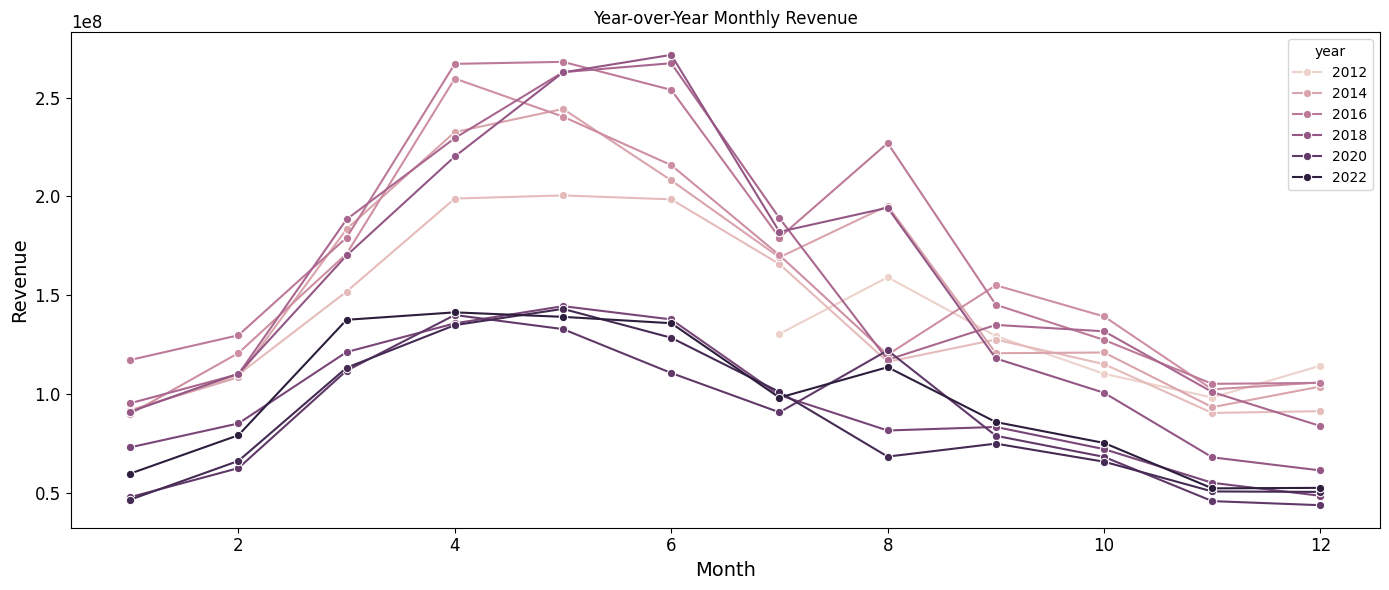

In [7]:
yoy = sales.groupby(["year", "month"], as_index=False)["Revenue"].sum()

plt.figure(figsize=(14,6))
sns.lineplot(data=yoy, x="month", y="Revenue", hue="year", marker="o")
plt.title("Year-over-Year Monthly Revenue")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.tight_layout()
save_fig('yoy_montly_revenue')
plt.show()

Saving figure dow_avg_revenue


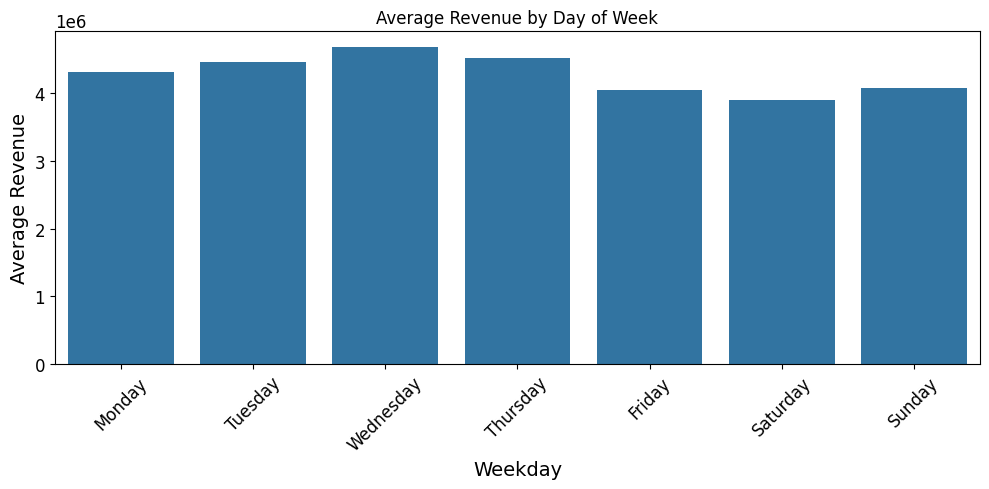

In [8]:
sales["weekday"] = sales["Date"].dt.day_name()

weekday_order = [
    "Monday", "Tuesday", "Wednesday", "Thursday",
    "Friday", "Saturday", "Sunday"
]

weekday_rev = sales.groupby("weekday", as_index=False)["Revenue"].mean()
weekday_rev["weekday"] = pd.Categorical(weekday_rev["weekday"], categories=weekday_order, ordered=True)
weekday_rev = weekday_rev.sort_values("weekday")

plt.figure(figsize=(10,5))
sns.barplot(data=weekday_rev, x="weekday", y="Revenue")
plt.title("Average Revenue by Day of Week")
plt.xlabel("Weekday")
plt.ylabel("Average Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
save_fig('dow_avg_revenue')
plt.show()

### Revenue theo category / segment

In [9]:
order_items["line_revenue"] = order_items["quantity"] * order_items["unit_price"]

order_detail = (
    order_items
    .merge(products, on="product_id", how="left")
    .merge(orders[["order_id", "order_date", "zip", "device_type", "order_source", "payment_method", "order_status"]],
           on="order_id", how="left")
)

Saving figure product_cate_revenue


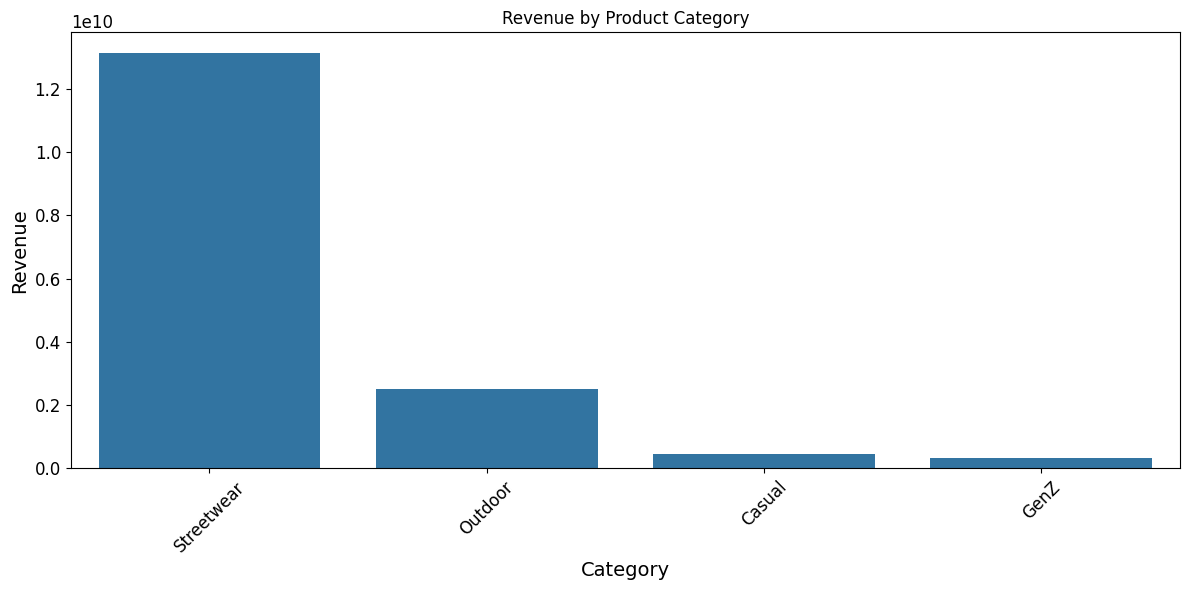

In [10]:
cat_rev = (
    order_detail.groupby("category", as_index=False)["line_revenue"]
    .sum()
    .sort_values("line_revenue", ascending=False)
)

plt.figure(figsize=(12,6))
sns.barplot(data=cat_rev, x="category", y="line_revenue")
plt.title("Revenue by Product Category")
plt.xlabel("Category")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
save_fig('product_cate_revenue')
plt.show()

Saving figure product_segement_revenue


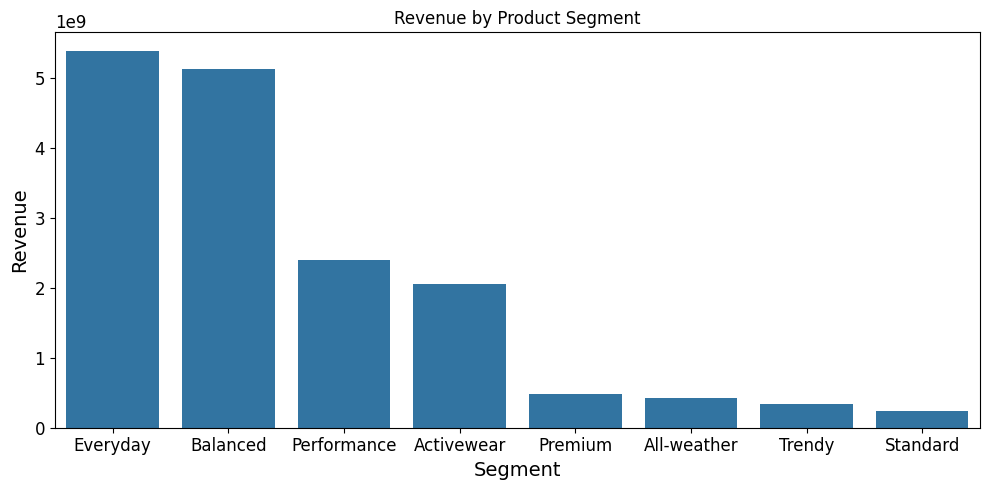

In [11]:
seg_rev = (
    order_detail.groupby("segment", as_index=False)["line_revenue"]
    .sum()
    .sort_values("line_revenue", ascending=False)
)

plt.figure(figsize=(10,5))
sns.barplot(data=seg_rev, x="segment", y="line_revenue")
plt.title("Revenue by Product Segment")
plt.xlabel("Segment")
plt.ylabel("Revenue")
plt.tight_layout()
save_fig('product_segement_revenue')
plt.show()

Saving figure cate_revenue_over_time


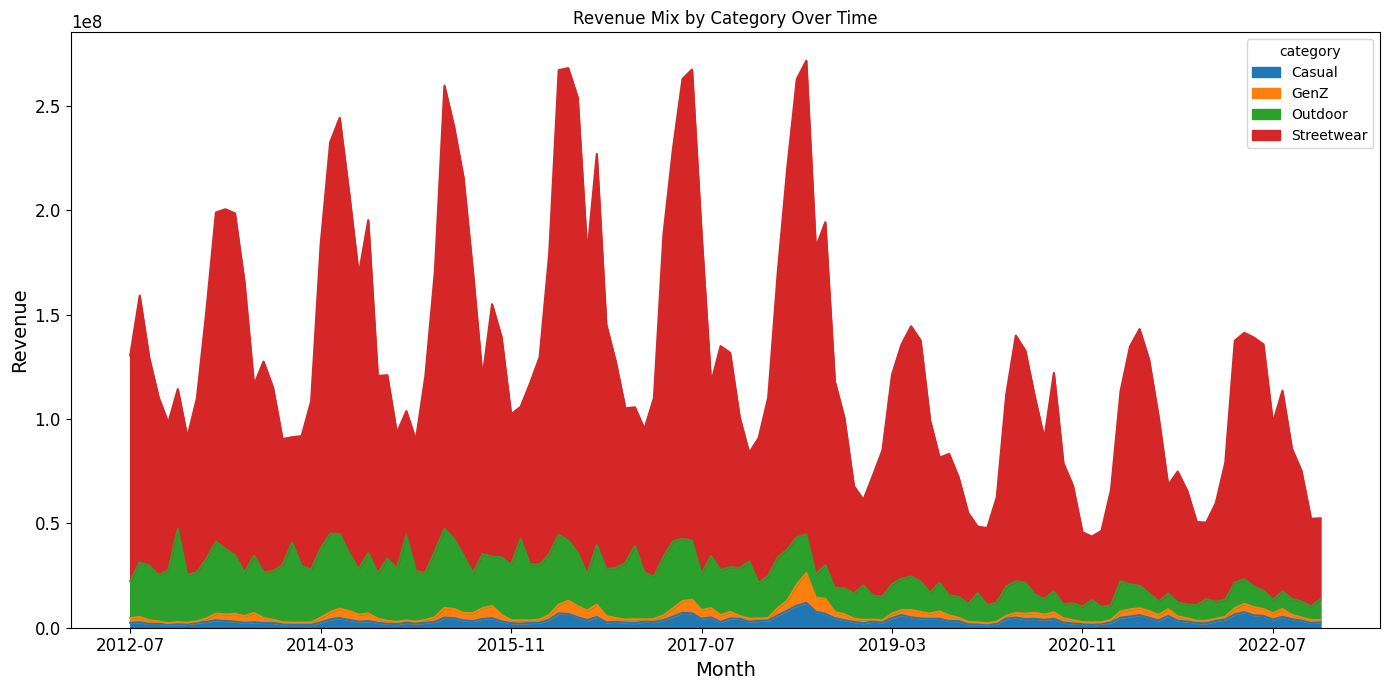

In [12]:
order_detail["year_month"] = order_detail["order_date"].dt.to_period("M").astype(str)

cat_month = (
    order_detail.groupby(["year_month", "category"], as_index=False)["line_revenue"]
    .sum()
)

pivot_cat_month = cat_month.pivot(index="year_month", columns="category", values="line_revenue").fillna(0)

pivot_cat_month.plot(kind="area", stacked=True, figsize=(14,7))
plt.title("Revenue Mix by Category Over Time")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.tight_layout()
save_fig('cate_revenue_over_time')
plt.show()

### Revenue theo region / city

In [13]:
geo_detail = order_detail.merge(
    geography[["zip", "city", "region", "district"]],
    on="zip",
    how="left"
)

Saving figure region_rev


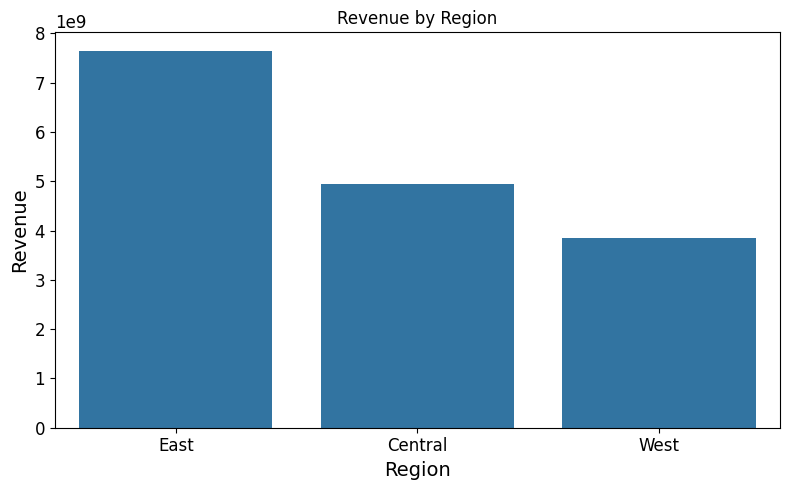

In [14]:
region_rev = (
    geo_detail.groupby("region", as_index=False)["line_revenue"]
    .sum()
    .sort_values("line_revenue", ascending=False)
)

plt.figure(figsize=(8,5))
sns.barplot(data=region_rev, x="region", y="line_revenue")
plt.title("Revenue by Region")
plt.xlabel("Region")
plt.ylabel("Revenue")
plt.tight_layout()
save_fig('region_rev')
plt.show()

Saving figure top10rev_by_city


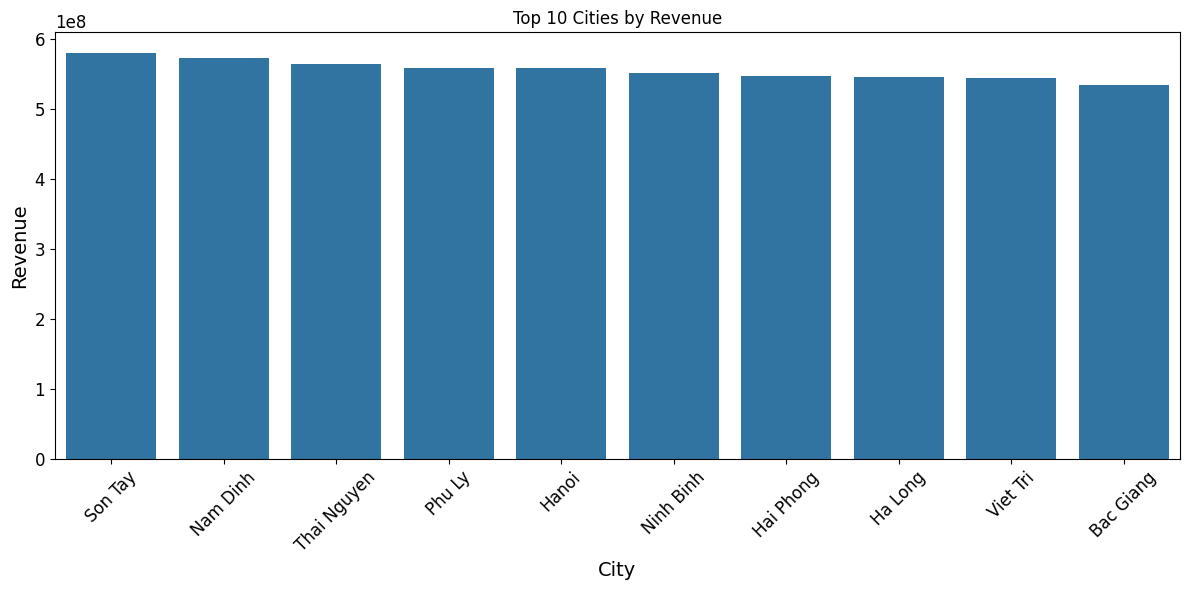

In [15]:
city_rev = (
    geo_detail.groupby("city", as_index=False)["line_revenue"]
    .sum()
    .sort_values("line_revenue", ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))
sns.barplot(data=city_rev, x="city", y="line_revenue")
plt.title("Top 10 Cities by Revenue")
plt.xlabel("City")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
save_fig('top10rev_by_city')
plt.show()

### Revenue theo device / source / payment

Saving figure device_rev


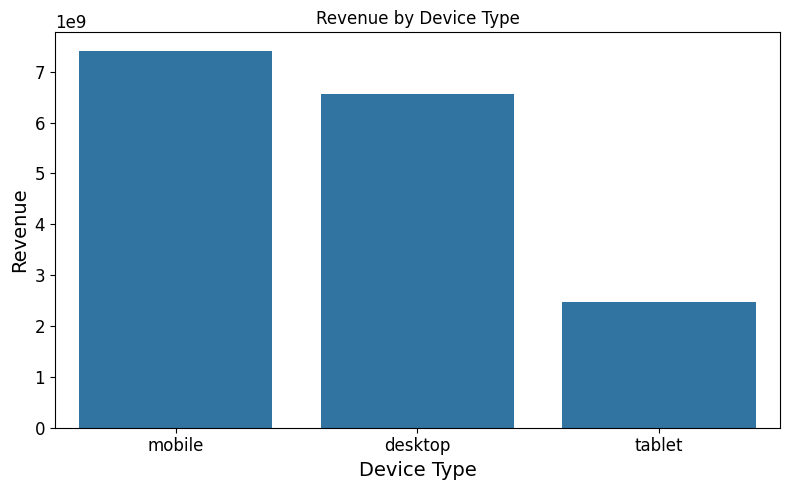

In [16]:
device_rev = (
    order_detail.groupby("device_type", as_index=False)["line_revenue"]
    .sum()
    .sort_values("line_revenue", ascending=False)
)

plt.figure(figsize=(8,5))
sns.barplot(data=device_rev, x="device_type", y="line_revenue")
plt.title("Revenue by Device Type")
plt.xlabel("Device Type")
plt.ylabel("Revenue")
plt.tight_layout()
save_fig('device_rev')
plt.show()

Saving figure order_src_rev


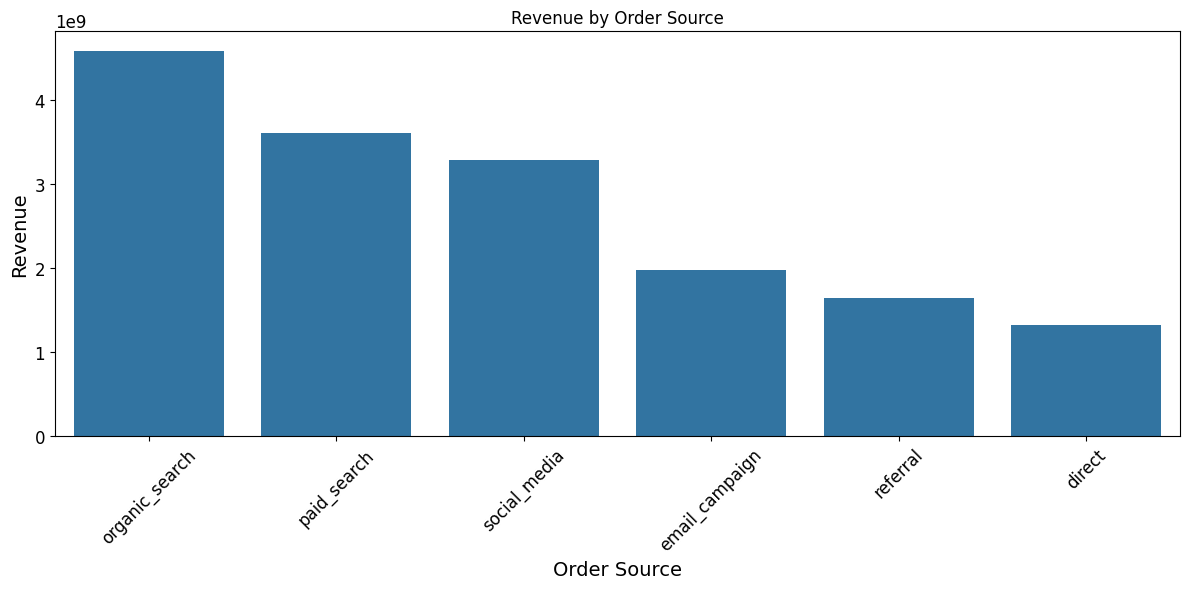

In [17]:
source_rev = (
    order_detail.groupby("order_source", as_index=False)["line_revenue"]
    .sum()
    .sort_values("line_revenue", ascending=False)
)

plt.figure(figsize=(12,6))
sns.barplot(data=source_rev, x="order_source", y="line_revenue")
plt.title("Revenue by Order Source")
plt.xlabel("Order Source")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
save_fig('order_src_rev')
plt.show()

Saving figure payment_method_revenue


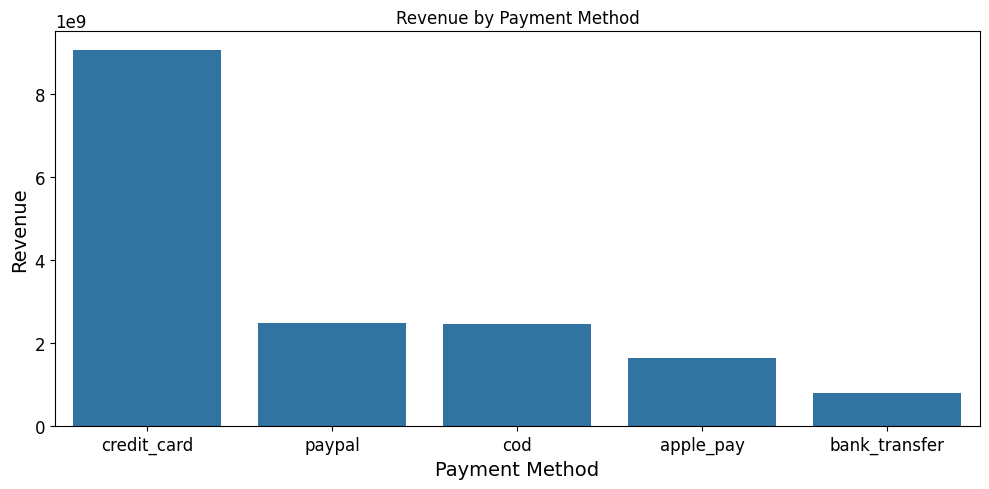

In [18]:
payment_rev = (
    order_detail.groupby("payment_method", as_index=False)["line_revenue"]
    .sum()
    .sort_values("line_revenue", ascending=False)
)

plt.figure(figsize=(10,5))
sns.barplot(data=payment_rev, x="payment_method", y="line_revenue")
plt.title("Revenue by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Revenue")
plt.tight_layout()
save_fig('payment_method_revenue')
plt.show()

### Orders và AOV

In [19]:
order_revenue = (
    order_detail.groupby("order_id", as_index=False)["line_revenue"]
    .sum()
    .merge(orders[["order_id", "order_date"]], on="order_id", how="left")
)

order_revenue["year_month"] = order_revenue["order_date"].dt.to_period("M").dt.to_timestamp()

monthly_orders = order_revenue.groupby("year_month", as_index=False).agg(
    total_revenue=("line_revenue", "sum"),
    order_count=("order_id", "nunique")
)

monthly_orders["AOV"] = monthly_orders["total_revenue"] / monthly_orders["order_count"]

Saving figure monthly_ord_count


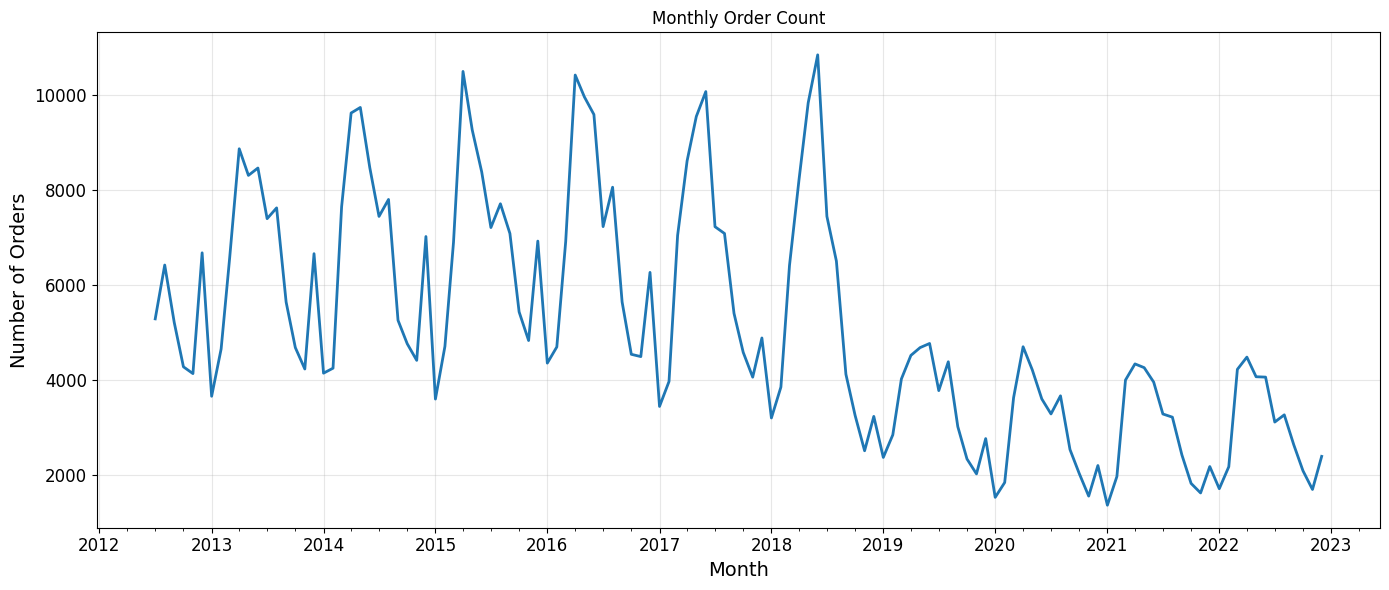

In [20]:
plt.figure(figsize=(14,6))
plt.plot(monthly_orders["year_month"], monthly_orders["order_count"],linewidth=2)
plt.title("Monthly Order Count")
plt.xlabel("Month")
plt.ylabel("Number of Orders")

plt.gca().xaxis.set_major_locator(mdates.YearLocator(1))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.gca().xaxis.set_minor_locator(mdates.MonthLocator(interval=3))

plt.grid(True, alpha=0.3)
plt.tight_layout()

save_fig('monthly_ord_count')
plt.show()

Saving figure monthly_aov


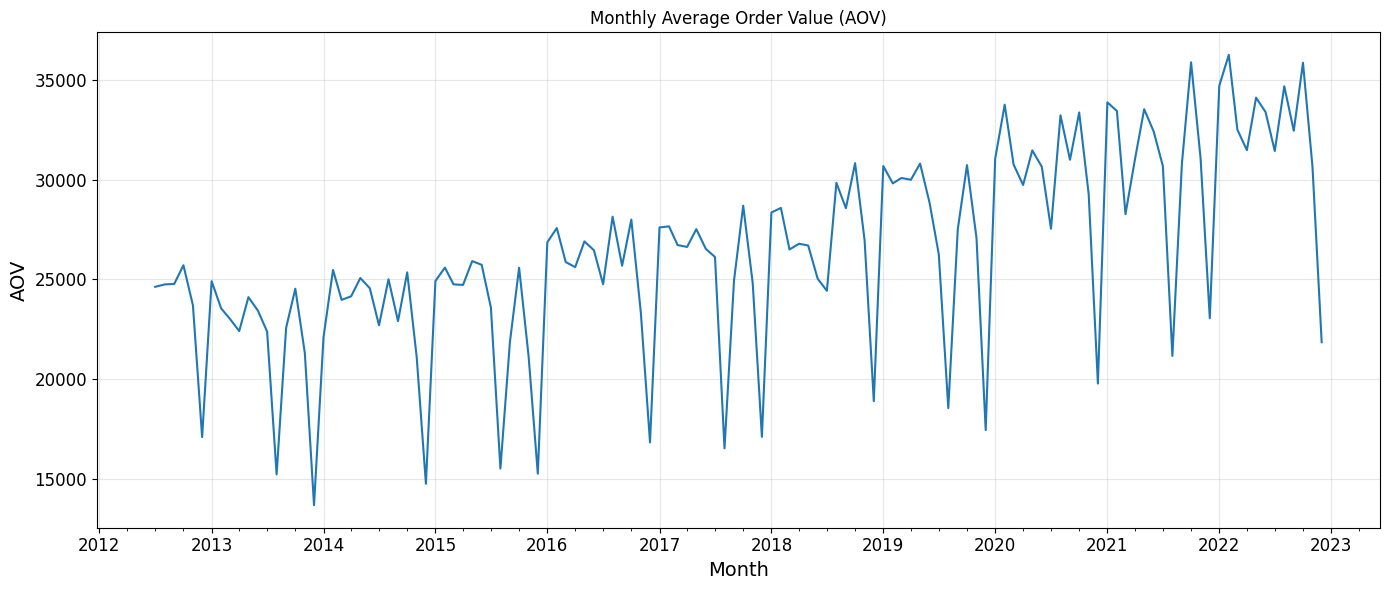

In [21]:
plt.figure(figsize=(14,6))
plt.plot(monthly_orders["year_month"], monthly_orders["AOV"])
plt.title("Monthly Average Order Value (AOV)")
plt.xlabel("Month")
plt.ylabel("AOV")

plt.gca().xaxis.set_major_locator(mdates.YearLocator(1))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.gca().xaxis.set_minor_locator(mdates.MonthLocator(interval=3))

plt.grid(True, alpha=0.3)
plt.tight_layout()

save_fig('monthly_aov')
plt.show()